In [107]:
import os

print(os.getcwd())

c:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [108]:
print(os.listdir())

['05_advanced_analytics.ipynb', 'alpha_beta.csv', 'benchmark_comparison.csv', 'Benchmark_Comparison.ipynb', 'benchmark_comparison_chart.png', 'bluestock_mf.db', 'day2_data_cleaning.ipynb', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'Investor_Analysis.ipynb', 'Performance_Analytics.ipynb', 'rolling_sharpe_chart.png', 'test.png', 'top10_fund_score.png', 'var_cvar_report.csv']


In [109]:
df = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\08_investor_transactions.csv"
)

In [110]:
import os
print(os.getcwd())


c:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\notebooks


In [111]:
import os
print(os.listdir())

['05_advanced_analytics.ipynb', 'alpha_beta.csv', 'benchmark_comparison.csv', 'Benchmark_Comparison.ipynb', 'benchmark_comparison_chart.png', 'bluestock_mf.db', 'day2_data_cleaning.ipynb', 'EDA_Analysis.ipynb', 'fund_scorecard.csv', 'Investor_Analysis.ipynb', 'Performance_Analytics.ipynb', 'rolling_sharpe_chart.png', 'test.png', 'top10_fund_score.png', 'var_cvar_report.csv']


In [112]:
df = pd.read_csv(
r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\08_investor_transactions.csv"
)

In [113]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("bluestock_mf.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

               name
0          fact_nav
1  fact_transaction


In [114]:
nav = pd.read_sql("SELECT * FROM fact_nav", conn)
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03 00:00:00.000000,520.4608
1,100016,2022-01-04 00:00:00.000000,515.0971
2,100016,2022-01-05 00:00:00.000000,521.7239
3,100016,2022-01-06 00:00:00.000000,515.7880
4,100016,2022-01-07 00:00:00.000000,515.1639


In [115]:
nav['date'] = pd.to_datetime(nav['date'])

returns = nav.pivot(index='date', columns='amfi_code', values='nav')

returns = returns.pct_change().dropna()

In [116]:
VaR_95 = returns.quantile(0.05)
CVaR_95 = returns[returns <= VaR_95].mean()

In [117]:
rolling_sharpe = (
    returns.rolling(90).mean() /
    returns.rolling(90).std()
) * 252**0.5

In [118]:
VaR_95 = returns.quantile(0.05)
CVaR_95 = returns[returns <= VaR_95].mean()

In [119]:
VaR_95 = returns.quantile(0.05)
CVaR_95 = returns[returns <= VaR_95].mean()

In [120]:
import pandas as pd

var_cvar_df = pd.DataFrame({
    "VaR_95": VaR_95,
    "CVaR_95": CVaR_95
})

In [121]:
var_cvar_df.to_csv("var_cvar_report.csv")

In [122]:
rolling_sharpe = (
    returns.rolling(90).mean() /
    returns.rolling(90).std()
) * (252 ** 0.5)

In [123]:
selected = returns.columns[:5]

In [124]:
volatility = returns.std().sort_values(ascending=False)
volatility.head(10)

amfi_code
101207    0.016251
118634    0.015901
119598    0.015837
119095    0.015790
119599    0.015717
149324    0.015648
119094    0.012225
120505    0.012152
100033    0.011929
125498    0.011561
dtype: float64

In [125]:
import pandas as pd

transactions = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\08_investor_transactions.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [126]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [127]:
transactions['cohort'] = transactions.groupby('investor_id')['transaction_date'].transform('min').dt.year

In [128]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort'],
      dtype='object')

In [129]:
transactions['transaction_date']

0       2024-01-01
1       2024-01-01
2       2024-01-01
3       2024-01-01
4       2024-01-01
           ...    
32773   2025-05-30
32774   2025-05-30
32775   2025-05-30
32776   2025-05-30
32777   2025-05-30
Name: transaction_date, Length: 32778, dtype: datetime64[ns]

In [130]:
VaR_95 = returns.quantile(0.05)
CVaR_95 = returns[returns <= VaR_95].mean()

In [131]:
var_cvar_df.to_csv("var_cvar_report.csv")

In [132]:
rolling_sharpe = (
    returns.rolling(90).mean() /
    returns.rolling(90).std()
) * (252 ** 0.5)

In [133]:
selected = returns.columns[:5]

In [134]:
plt.savefig("rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>

In [135]:
volatility = returns.std().sort_values(ascending=False)
volatility.head(10)

amfi_code
101207    0.016251
118634    0.015901
119598    0.015837
119095    0.015790
119599    0.015717
149324    0.015648
119094    0.012225
120505    0.012152
100033    0.011929
125498    0.011561
dtype: float64

In [136]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

In [137]:
transactions['cohort'] = transactions.groupby('investor_id')['transaction_date'].transform('min').dt.year

In [138]:
def recommend_funds(risk):
    filtered = funds[funds['risk_grade'] == risk]
    return filtered.sort_values('sharpe_ratio', ascending=False).head(3)

In [139]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("bluestock_mf.db")

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)

,name
0,fact_nav
1,fact_transaction


In [140]:
risk_summary = returns.std().reset_index()
risk_summary.columns = ['fund', 'volatility']
risk_summary.sort_values('volatility', ascending=False).head(10)

,fund,volatility
4,101207,0.016251
11,118634,0.015901
21,119598,0.015837
17,119095,0.015790
22,119599,0.015717
39,149324,0.015648
16,119094,0.012225
25,120505,0.012152
2,100033,0.011929
33,125498,0.011561


In [141]:
volatility = returns.std().sort_values(ascending=False)

volatility.head(10)

amfi_code
101207    0.016251
118634    0.015901
119598    0.015837
119095    0.015790
119599    0.015717
149324    0.015648
119094    0.012225
120505    0.012152
100033    0.011929
125498    0.011561
dtype: float64

In [142]:
transactions['gap'] = transactions.groupby('investor_id')['transaction_date'].diff().dt.days

at_risk = transactions.groupby('investor_id')['gap'].mean()
at_risk = at_risk[at_risk > 35]

In [143]:
transactions['cohort'] = transactions.groupby('investor_id')['transaction_date'].transform('min').dt.year

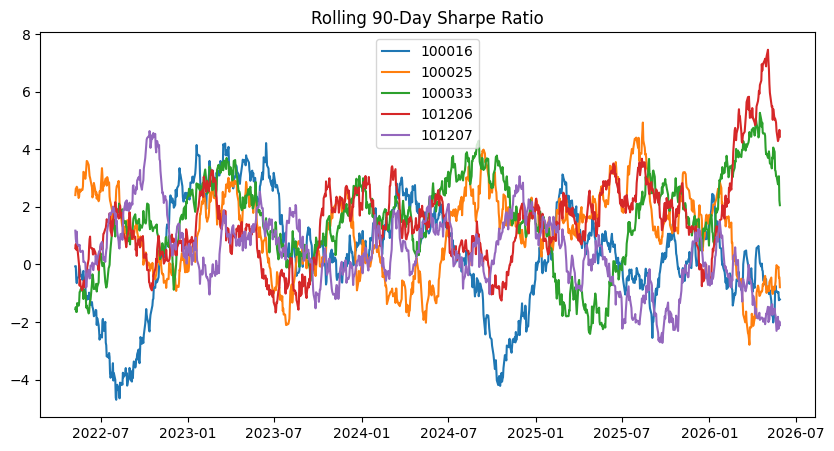

In [144]:
plt.figure(figsize=(10,5))

for col in rolling_sharpe.columns[:5]:
    plt.plot(rolling_sharpe.index, rolling_sharpe[col], label=col)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()

In [145]:
plt.savefig("rolling_sharpe_chart.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [146]:
plt.show()

In [147]:
import os
print(os.path.exists("rolling_sharpe_chart.png"))

True
